# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [ ]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 13.42 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
!ls MNIST

processed  raw


In [ ]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [ ]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [ ]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

if True:
    n_samples_val = 200

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

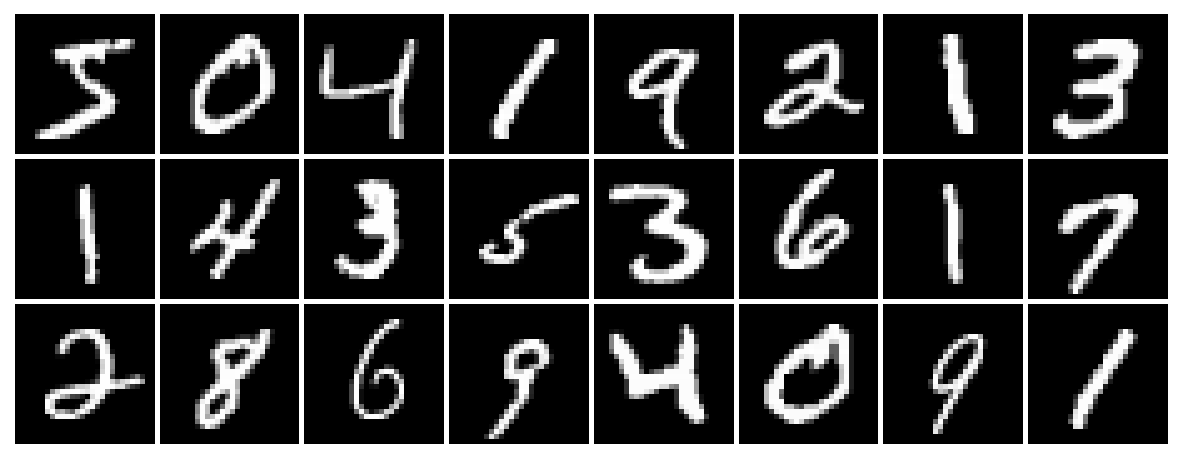

In [ ]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


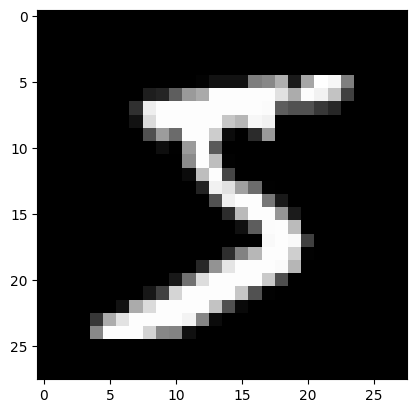

In [ ]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [ ]:
model = torch.nn.Linear(28*28, 10)

### Testando um predict com poucas amostras

In [ ]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.1392, -0.1329,  0.2461,  0.3659,  0.0829, -0.1476,  0.0203, -0.0397,
          0.3121, -0.1633],
        [-0.0299, -0.0004, -0.1785,  0.1068, -0.1806,  0.0604, -0.1464, -0.0576,
          0.3750,  0.2986],
        [-0.0952, -0.0524,  0.0427,  0.1155, -0.0618, -0.2063,  0.0083,  0.1219,
         -0.0421,  0.2993],
        [ 0.1804, -0.1347, -0.2227,  0.2803, -0.0873,  0.2156, -0.1474, -0.1283,
         -0.0606, -0.0045],
        [-0.0111, -0.0534, -0.4158,  0.1817, -0.0095,  0.2632, -0.0355, -0.1003,
          0.0322, -0.1608]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [ ]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [ ]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2649, Train Acc: 0.9400, Val Loss: 0.3963, Val Acc: 0.9000
Epoch [2/100], Train Loss: 0.2636, Train Acc: 0.9400, Val Loss: 0.3953, Val Acc: 0.9000
Epoch [3/100], Train Loss: 0.2623, Train Acc: 0.9400, Val Loss: 0.3944, Val Acc: 0.9000
Epoch [4/100], Train Loss: 0.2610, Train Acc: 0.9420, Val Loss: 0.3935, Val Acc: 0.9000
Epoch [5/100], Train Loss: 0.2597, Train Acc: 0.9430, Val Loss: 0.3926, Val Acc: 0.9000
Epoch [6/100], Train Loss: 0.2584, Train Acc: 0.9430, Val Loss: 0.3917, Val Acc: 0.9000
Epoch [7/100], Train Loss: 0.2572, Train Acc: 0.9430, Val Loss: 0.3908, Val Acc: 0.9000
Epoch [8/100], Train Loss: 0.2560, Train Acc: 0.9430, Val Loss: 0.3900, Val Acc: 0.9000
Epoch [9/100], Train Loss: 0.2547, Train Acc: 0.9430, Val Loss: 0.3891, Val Acc: 0.8950
Epoch [10/100], Train Loss: 0.2535, Train Acc: 0.9430, Val Loss: 0.3883, Val Acc: 0.8950
Epoch [11/100], Train Loss: 0.2523, Train Acc: 0.9440, Val Loss: 0.3875, Val Acc: 0.8950
Epoch [12/100], Train Loss: 0.

In [ ]:
print('Final loss:', loss.item())

Final loss: 0.2653433084487915


### Visualizando gráfico de perda durante o treinamento

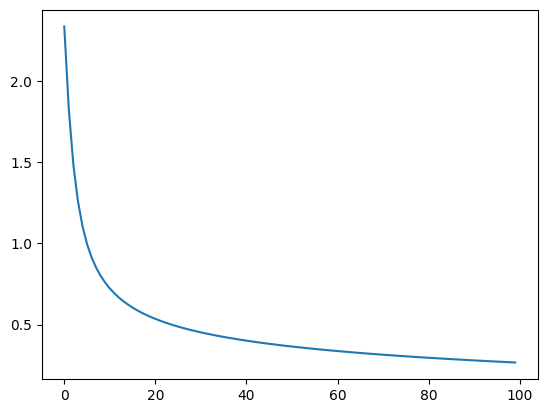

In [ ]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

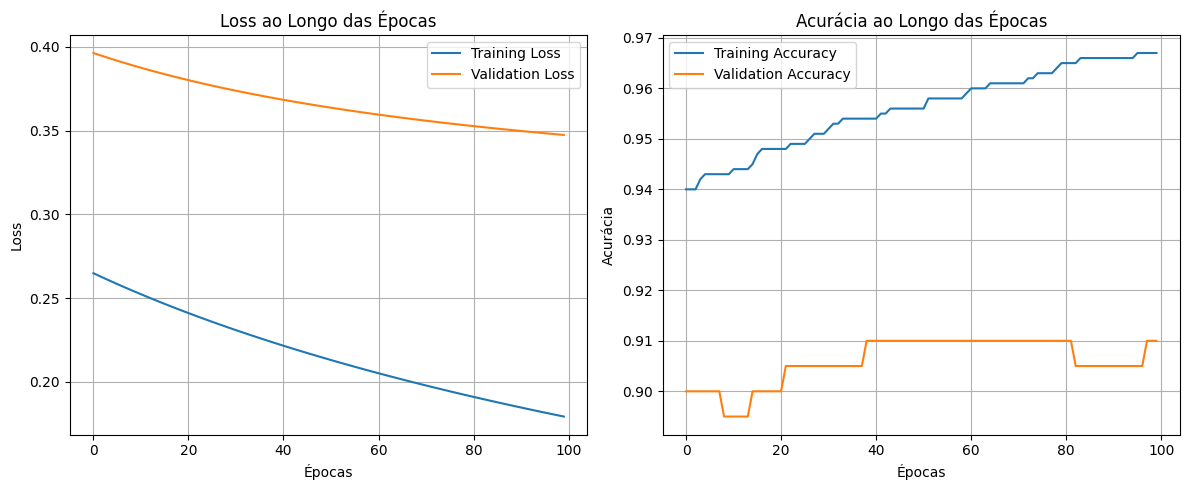

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [ ]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [ ]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


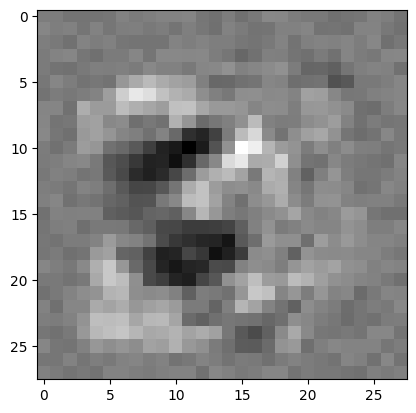

In [ ]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

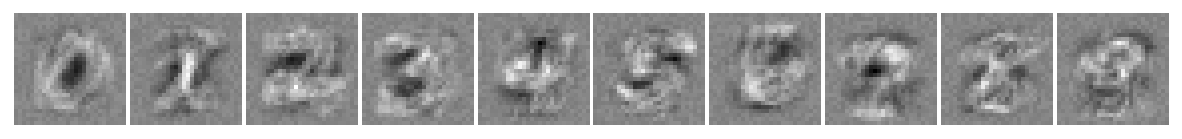

In [ ]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [ ]:
losses = []
zs = []

for i in range(epochs):

    inputs = Variable(x_train.view(-1, 28 * 28))
    outputs = model(inputs)

    zs.append(outputs[1].detach().numpy())

    loss = criterion(outputs, Variable(y_train))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch[{}/{}], perda: {:.6f}, acurácia: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))


Epoch[1/100], perda: 0.178777, acurácia: 0.967000
Epoch[2/100], perda: 0.178201, acurácia: 0.967000
Epoch[3/100], perda: 0.177630, acurácia: 0.967000
Epoch[4/100], perda: 0.177062, acurácia: 0.967000
Epoch[5/100], perda: 0.176497, acurácia: 0.967000
Epoch[6/100], perda: 0.175936, acurácia: 0.967000
Epoch[7/100], perda: 0.175379, acurácia: 0.967000
Epoch[8/100], perda: 0.174824, acurácia: 0.967000
Epoch[9/100], perda: 0.174274, acurácia: 0.967000
Epoch[10/100], perda: 0.173726, acurácia: 0.967000
Epoch[11/100], perda: 0.173182, acurácia: 0.967000
Epoch[12/100], perda: 0.172640, acurácia: 0.967000
Epoch[13/100], perda: 0.172103, acurácia: 0.967000
Epoch[14/100], perda: 0.171568, acurácia: 0.967000
Epoch[15/100], perda: 0.171036, acurácia: 0.967000
Epoch[16/100], perda: 0.170508, acurácia: 0.967000
Epoch[17/100], perda: 0.169982, acurácia: 0.967000
Epoch[18/100], perda: 0.169460, acurácia: 0.967000
Epoch[19/100], perda: 0.168941, acurácia: 0.967000
Epoch[20/100], perda: 0.168425, acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

Epoch[1/100], época 0.1152, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


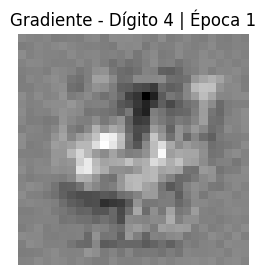

Epoch[2/100], época 0.1150, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


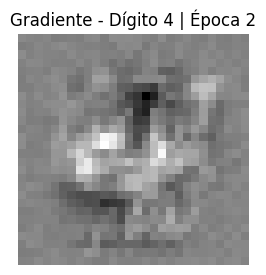

Epoch[3/100], época 0.1147, acurácia: 0.9870
weights: torch.Size([10, 784])
bias: torch.Size([10])


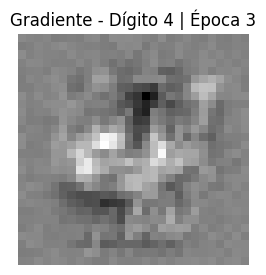

Epoch[4/100], época 0.1145, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


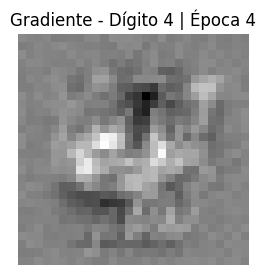

Epoch[5/100], época 0.1142, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


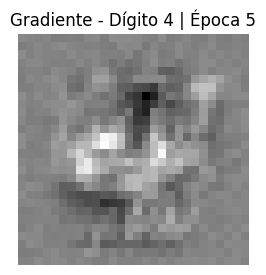

Epoch[6/100], época 0.1140, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


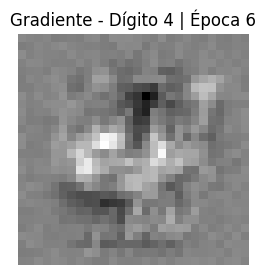

Epoch[7/100], época 0.1137, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


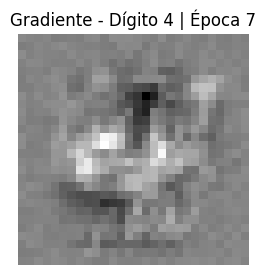

Epoch[8/100], época 0.1135, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


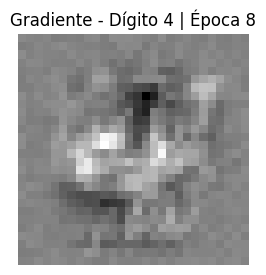

Epoch[9/100], época 0.1132, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


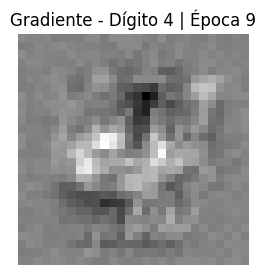

Epoch[10/100], época 0.1130, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


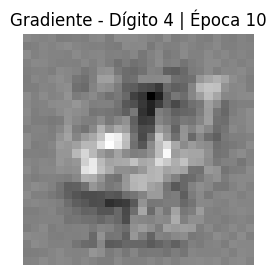

Epoch[11/100], época 0.1127, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


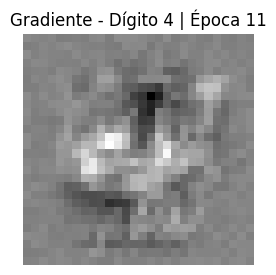

Epoch[12/100], época 0.1125, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


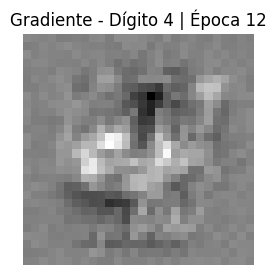

Epoch[13/100], época 0.1122, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


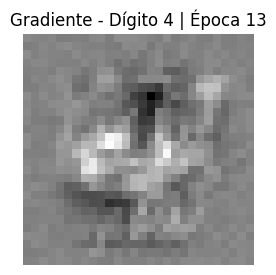

Epoch[14/100], época 0.1120, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


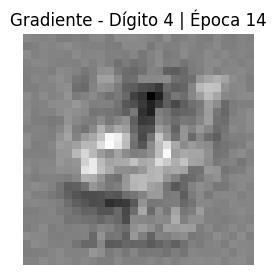

Epoch[15/100], época 0.1117, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


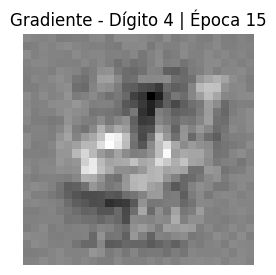

Epoch[16/100], época 0.1115, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


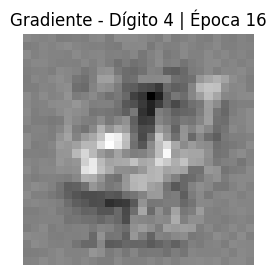

Epoch[17/100], época 0.1112, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


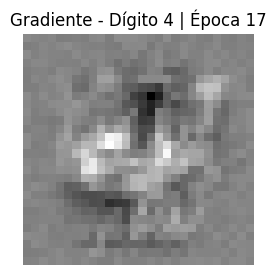

Epoch[18/100], época 0.1110, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


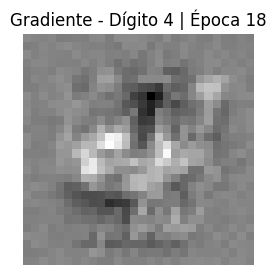

Epoch[19/100], época 0.1108, acurácia: 0.9880
weights: torch.Size([10, 784])
bias: torch.Size([10])


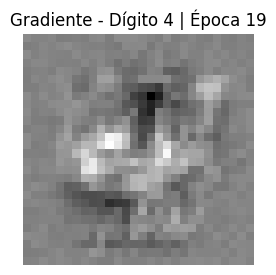

Epoch[20/100], época 0.1105, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


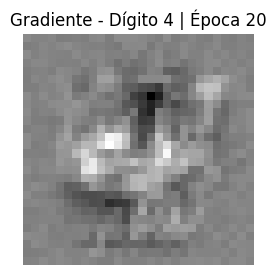

Epoch[21/100], época 0.1103, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


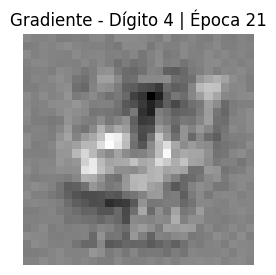

Epoch[22/100], época 0.1100, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


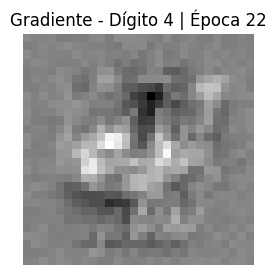

Epoch[23/100], época 0.1098, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


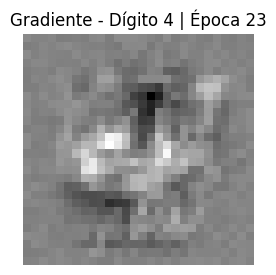

Epoch[24/100], época 0.1096, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


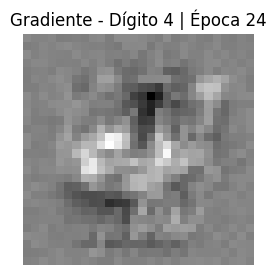

Epoch[25/100], época 0.1093, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


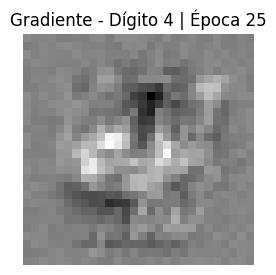

Epoch[26/100], época 0.1091, acurácia: 0.9890
weights: torch.Size([10, 784])
bias: torch.Size([10])


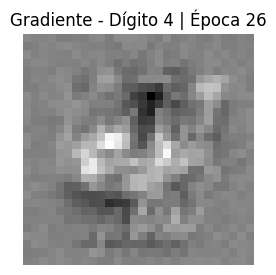

Epoch[27/100], época 0.1089, acurácia: 0.9900
weights: torch.Size([10, 784])
bias: torch.Size([10])


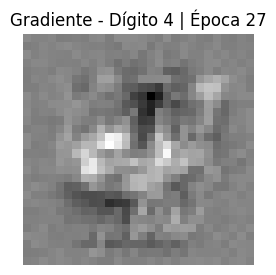

Epoch[28/100], época 0.1086, acurácia: 0.9900
weights: torch.Size([10, 784])
bias: torch.Size([10])


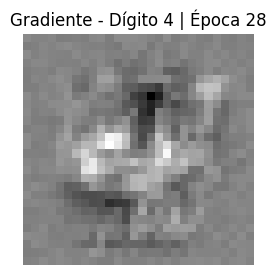

Epoch[29/100], época 0.1084, acurácia: 0.9900
weights: torch.Size([10, 784])
bias: torch.Size([10])


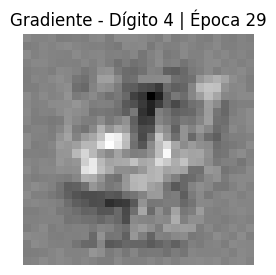

Epoch[30/100], época 0.1082, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


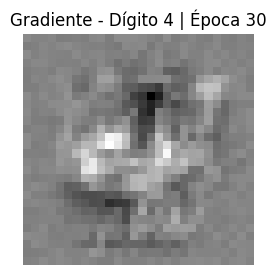

Epoch[31/100], época 0.1079, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


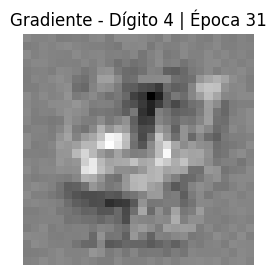

Epoch[32/100], época 0.1077, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


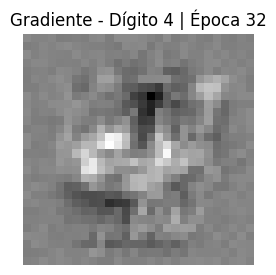

Epoch[33/100], época 0.1075, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


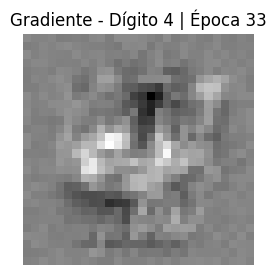

Epoch[34/100], época 0.1073, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


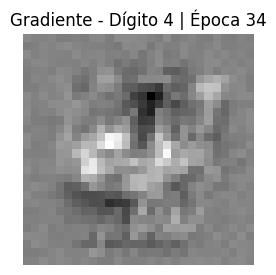

Epoch[35/100], época 0.1070, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


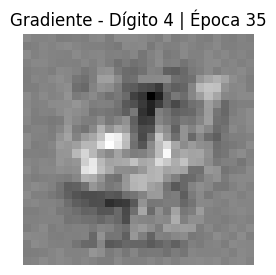

Epoch[36/100], época 0.1068, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


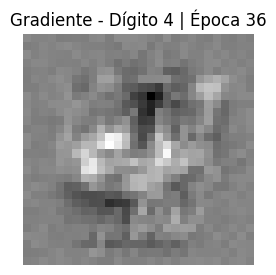

Epoch[37/100], época 0.1066, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


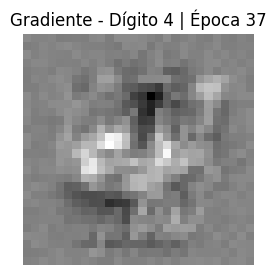

Epoch[38/100], época 0.1064, acurácia: 0.9910
weights: torch.Size([10, 784])
bias: torch.Size([10])


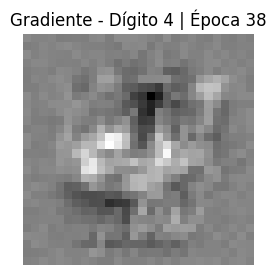

Epoch[39/100], época 0.1061, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


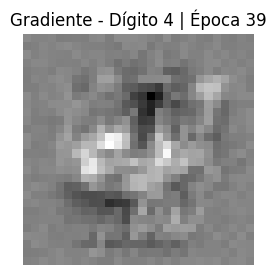

Epoch[40/100], época 0.1059, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


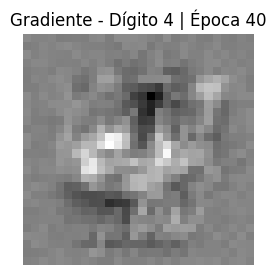

Epoch[41/100], época 0.1057, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


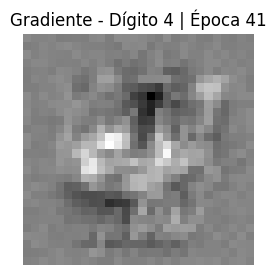

Epoch[42/100], época 0.1055, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


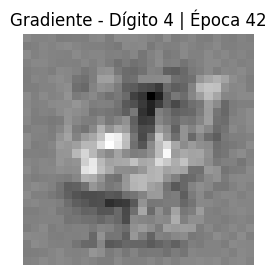

Epoch[43/100], época 0.1052, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


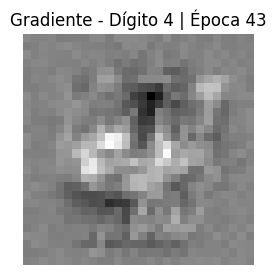

Epoch[44/100], época 0.1050, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


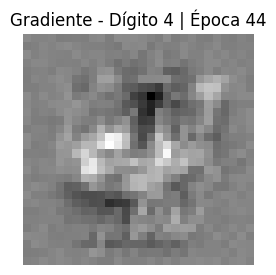

Epoch[45/100], época 0.1048, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


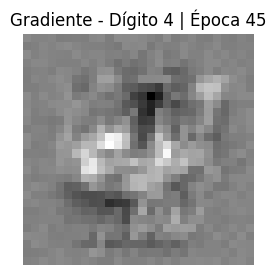

Epoch[46/100], época 0.1046, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


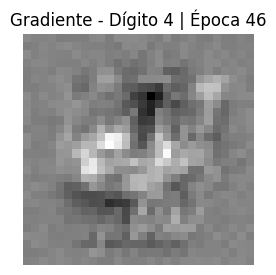

Epoch[47/100], época 0.1044, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


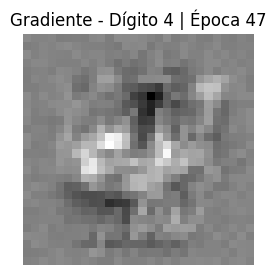

Epoch[48/100], época 0.1042, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


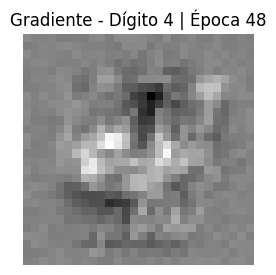

Epoch[49/100], época 0.1039, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


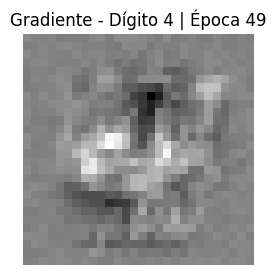

Epoch[50/100], época 0.1037, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


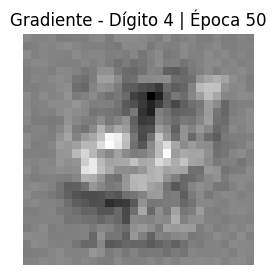

Epoch[51/100], época 0.1035, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


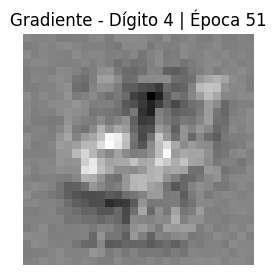

Epoch[52/100], época 0.1033, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


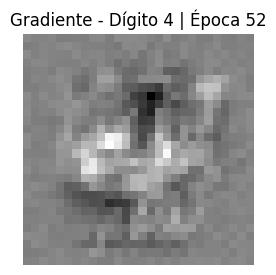

Epoch[53/100], época 0.1031, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


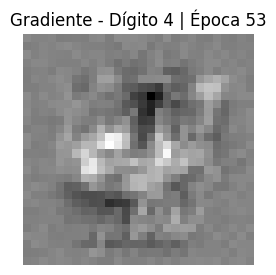

Epoch[54/100], época 0.1029, acurácia: 0.9920
weights: torch.Size([10, 784])
bias: torch.Size([10])


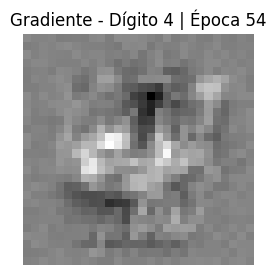

Epoch[55/100], época 0.1027, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


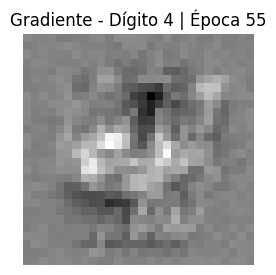

Epoch[56/100], época 0.1025, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


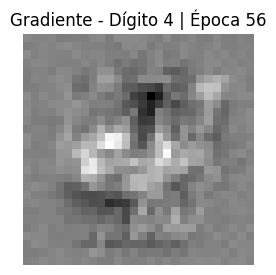

Epoch[57/100], época 0.1023, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


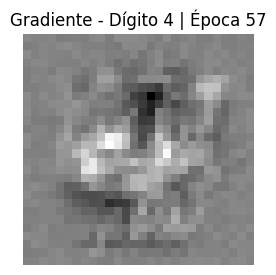

Epoch[58/100], época 0.1020, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


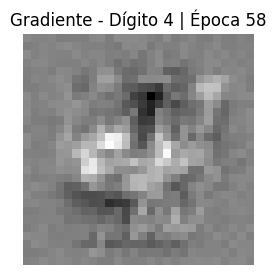

Epoch[59/100], época 0.1018, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


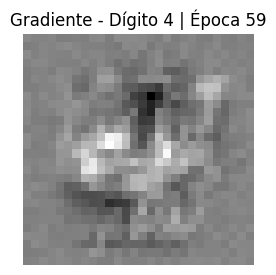

Epoch[60/100], época 0.1016, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


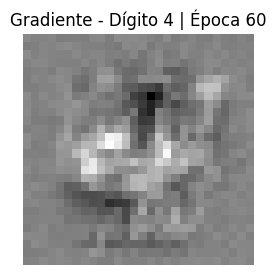

Epoch[61/100], época 0.1014, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


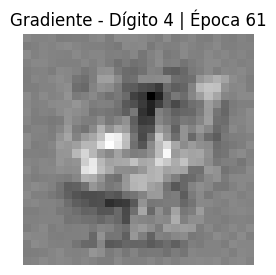

Epoch[62/100], época 0.1012, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


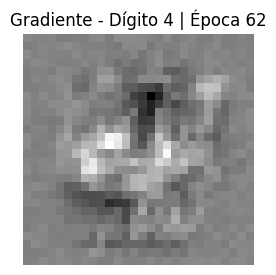

Epoch[63/100], época 0.1010, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


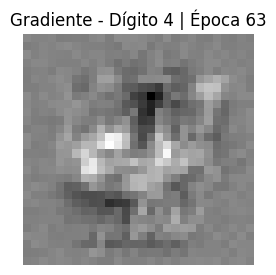

Epoch[64/100], época 0.1008, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


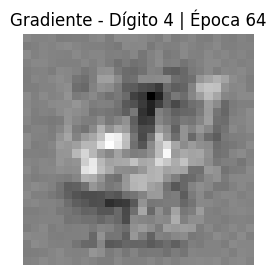

Epoch[65/100], época 0.1006, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


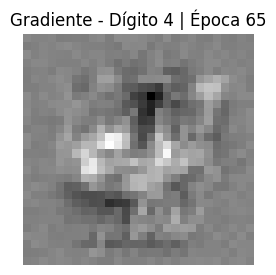

Epoch[66/100], época 0.1004, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


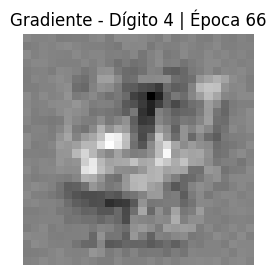

Epoch[67/100], época 0.1002, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


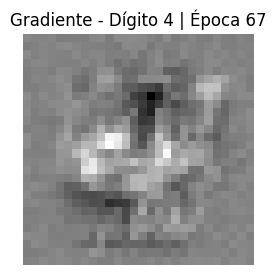

Epoch[68/100], época 0.1000, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


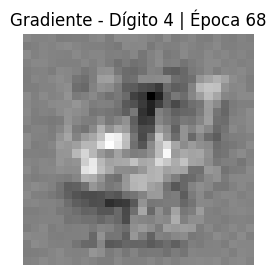

Epoch[69/100], época 0.0998, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


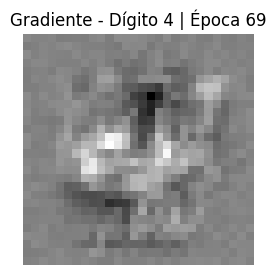

Epoch[70/100], época 0.0996, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


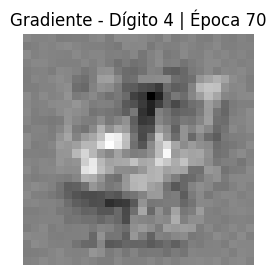

Epoch[71/100], época 0.0994, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


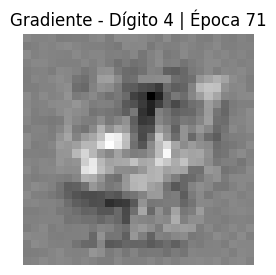

Epoch[72/100], época 0.0992, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


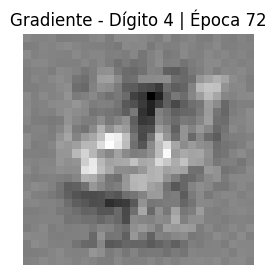

Epoch[73/100], época 0.0990, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


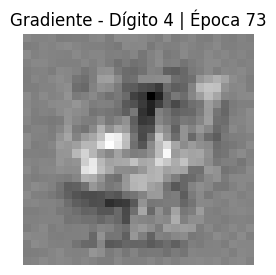

Epoch[74/100], época 0.0988, acurácia: 0.9930
weights: torch.Size([10, 784])
bias: torch.Size([10])


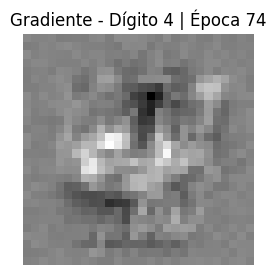

Epoch[75/100], época 0.0986, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


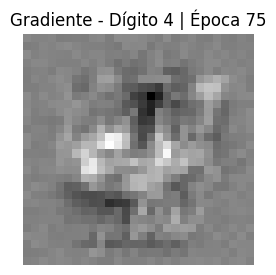

Epoch[76/100], época 0.0984, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


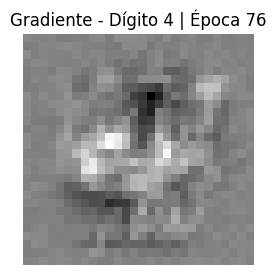

Epoch[77/100], época 0.0982, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


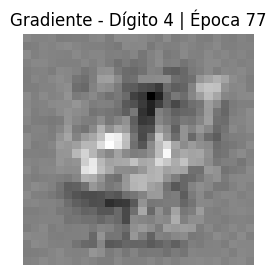

Epoch[78/100], época 0.0980, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


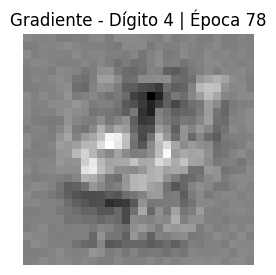

Epoch[79/100], época 0.0979, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


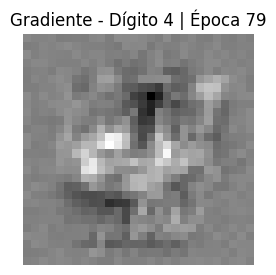

Epoch[80/100], época 0.0977, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


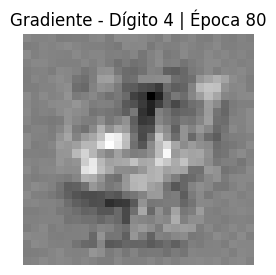

Epoch[81/100], época 0.0975, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


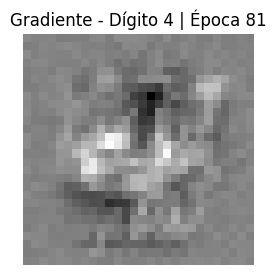

Epoch[82/100], época 0.0973, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


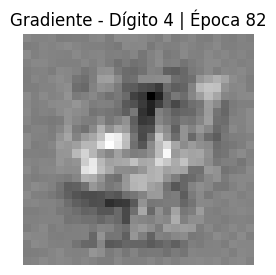

Epoch[83/100], época 0.0971, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


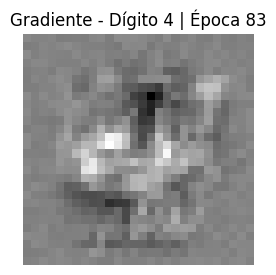

Epoch[84/100], época 0.0969, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


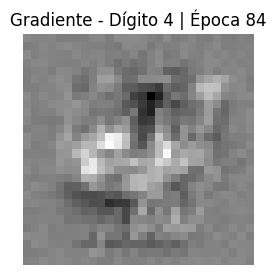

Epoch[85/100], época 0.0967, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


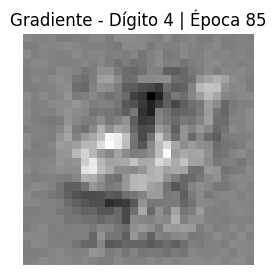

Epoch[86/100], época 0.0965, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


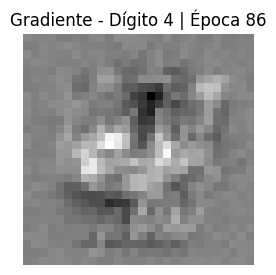

Epoch[87/100], época 0.0963, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


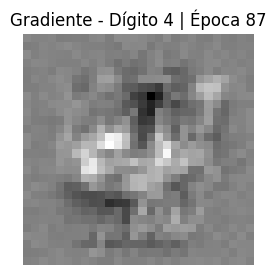

Epoch[88/100], época 0.0962, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


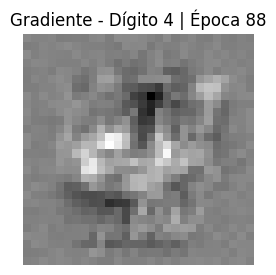

Epoch[89/100], época 0.0960, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


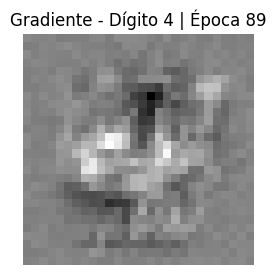

Epoch[90/100], época 0.0958, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


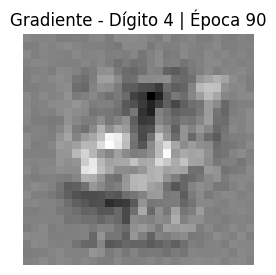

Epoch[91/100], época 0.0956, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


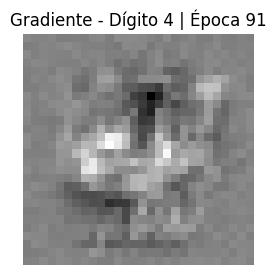

Epoch[92/100], época 0.0954, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


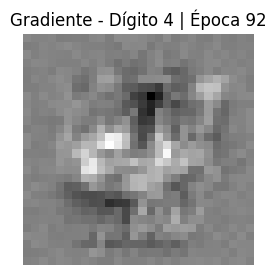

Epoch[93/100], época 0.0952, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


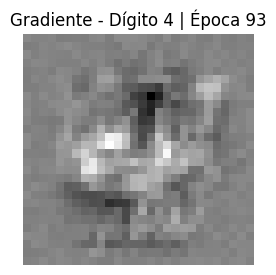

Epoch[94/100], época 0.0950, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


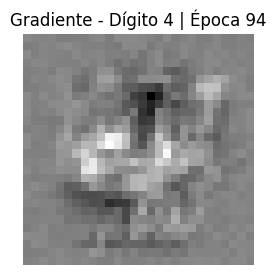

Epoch[95/100], época 0.0949, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


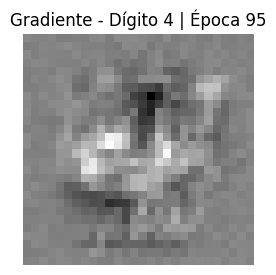

Epoch[96/100], época 0.0947, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


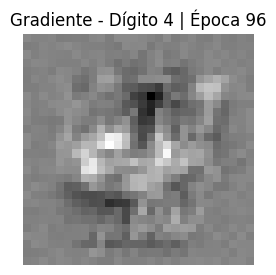

Epoch[97/100], época 0.0945, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


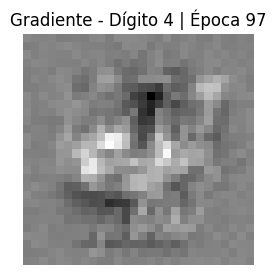

Epoch[98/100], época 0.0943, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


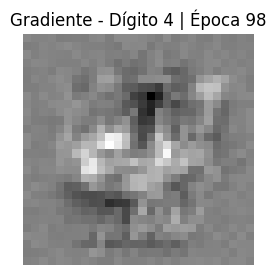

Epoch[99/100], época 0.0941, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


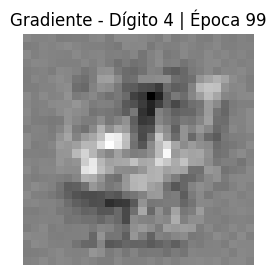

Epoch[100/100], época 0.0940, acurácia: 0.9940
weights: torch.Size([10, 784])
bias: torch.Size([10])


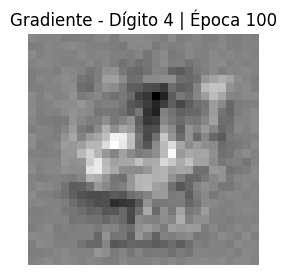

In [ ]:
losses = []
zs = []

for i in range(epochs):
    inputs = Variable(x_train.view(-1, 28 * 28))

    outputs = model(inputs)

    zs.append(outputs[1].detach().numpy())

    loss = criterion(outputs, Variable(y_train))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch[{}/{}], época {:.4f}, acurácia: {:.4f}' .format(i+1, epochs, loss.data, accuracy))

#EXERCÍCIO 02
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:', bias.shape)

    plt.figure(figsize=(3, 3))
    plt.imshow(weights[4, :].numpy().reshape(28, 28), cmap='gray')
    plt.title(f'Gradiente - Dígito 4 | Época {i+1}')
    plt.axis('off')
    plt.show()

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

1. Qual é o shape da matriz de entrada na rede?

        R.: [1000, 784]

2. Qual é o shape da saída da rede?

        R.: [1, 10]

3. Qual é o número total de parâmetros da rede, incluindo o bias?

        R.: 7840 parametros na rede + 10 bias = 7850 params

# Aprendizados


O numéro de parâmetros de uma rede é proporcional a entrada e aos números de classe, o que afeta a capacidade e o custo computacional do modelo e a sua demanda computacional.

O monitoramento da perda e da acurácia é importante para entender o comportamento do modelo e detectar problemas como overfitting e underfitting.